## Laborator 6  -  Rezolvarea unor probleme de regresie prin metode de învățare automată

#### 💡 Probleme

Ce fel de floare preferi?

Se consideră problema clasificării florilor de iris în diferite specii precum: setosa, versicolor și virginica. Pentru fiecare floare se cunosc caracteristici precum: lungimea și lățimea sepalei, lungimea și lățimea petalei. Mai multe detalii despre acest set se pot găsi aici. Folosindu-se aceste informații, să se decidă din ce specie aparține o anumită floare.

#### 📝 Cerinte

Specificaţi, proiectaţi, implementaţi si testati cate un algoritm de clasificare pentru problema 2 si problema 3 bazat pe regresie logistica. Antrenati cate un clasificator pentru fiecare problema, pe care apoi sa ii utilizati pentru a stabili:

* specia unei flori de iris care are sepala lunga de 5.35 cm si lata de 3.85 cm, iar petala lunga de 1.25 cm si lata de 0.4cm


###### 🏵️ Cerinte opționale

Rezolvarea unei probleme de regresie/clasificare prin:

folosirea validarii încrucișate
investigarea diferitelor funcții de loss
ce se întîmplă în cazul clasificarii binare daca se modifică pragul de decizie din 0.5 în alte valori. Cum se poate aprecia calitatea clasificatorului pentru diferite valori ale pragului?

cu tool

Accuracy of the multiclass Logistic Regression model: 1.00
The predicted species for the flower is: Iris-setosa


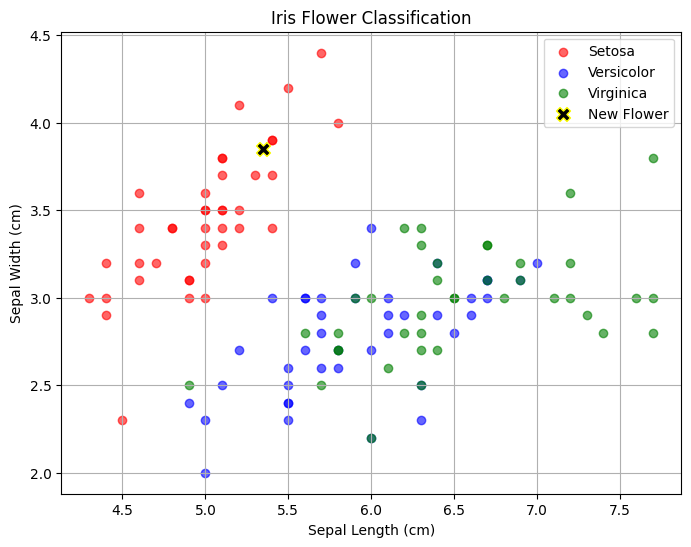

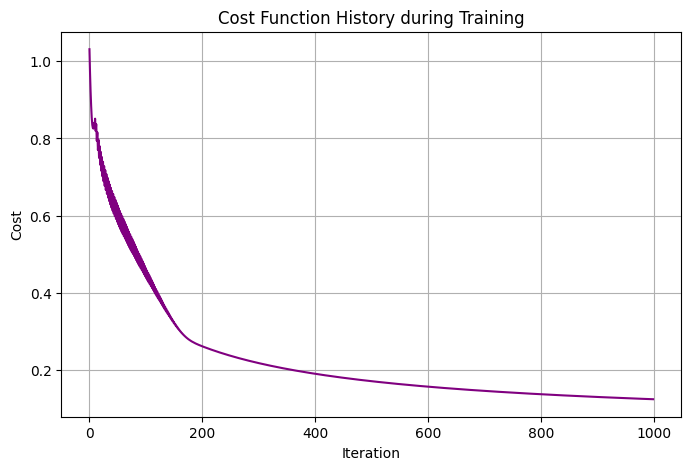

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def loadData(path):
    df = pd.read_csv(path, header=None)
    columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
    df.columns = columns

    # map species to numbers
    species_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
    df['species'] = df['species'].map(species_mapping)

    X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
    y = df['species'].values

    return X, y, df

# softmax function: for multiclass classification
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # prevent overflow
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# cost function for multiclass logistic regression
def compute_cost(X, y, theta, epsilon=1e-5):
    m = len(y)
    logits = X.dot(theta)
    probs = softmax(logits)

    # create one-hot encoding for y
    y_one_hot = np.eye(theta.shape[1])[y]

    # clip probs to avoid log(0)
    probs = np.clip(probs, epsilon, 1 - epsilon)
    cost = (-1/m) * np.sum(y_one_hot * np.log(probs))
    return cost

# Gradient Descent function
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        logits = X.dot(theta)
        probs = softmax(logits)

        y_one_hot = np.eye(theta.shape[1])[y]

        gradient = (1/m) * X.T.dot(probs - y_one_hot)
        theta -= learning_rate * gradient

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# predict function
def predict(X, theta):
    probs = softmax(X.dot(theta))
    return np.argmax(probs, axis=1)

X, y, df = loadData('iris.data')  # incarci local fisierul

X = np.c_[np.ones((X.shape[0], 1)), X]

# split train/test: 20-80
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialize theta
theta = np.zeros((X_train.shape[1], 3))  # 3 classes: setosa, versicolor, virginica

# train model
theta, cost_history = gradient_descent(X_train, y_train, theta, learning_rate=0.1, iterations=1000)

# evaluate model
y_pred = predict(X_test, theta)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy of the multiclass Logistic Regression model: {accuracy:.2f}")

# predict for a new flower
new_flower = np.array([1, 5.35, 3.85, 1.25, 0.4])  # Add intercept term
predicted_class = predict(new_flower.reshape(1, -1), theta)

species_mapping_inv = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
print(f"The predicted species for the flower is: {species_mapping_inv[predicted_class[0]]}")

# plot training data
plt.figure(figsize=(8,6))

# different colors for each class
colors = ['red', 'blue', 'green']
labels = ['Setosa', 'Versicolor', 'Virginica']

for i in range(3):
    plt.scatter(
        X_train[y_train == i][:, 1],  # sepal Length
        X_train[y_train == i][:, 2],  # sepal Width
        color=colors[i],
        label=labels[i],
        alpha=0.6
    )

# highlight new flower
plt.scatter(
    5.35, 3.85,
    color='black',
    label='New Flower',
    edgecolor='yellow',
    s=100,
    marker='X'
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Flower Classification')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot cost history
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='purple')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function History during Training')
plt.grid(True)
plt.show()


fara tool

Accuracy of the model (manual implementation): 1.00
The predicted species for the flower is: Iris-setosa


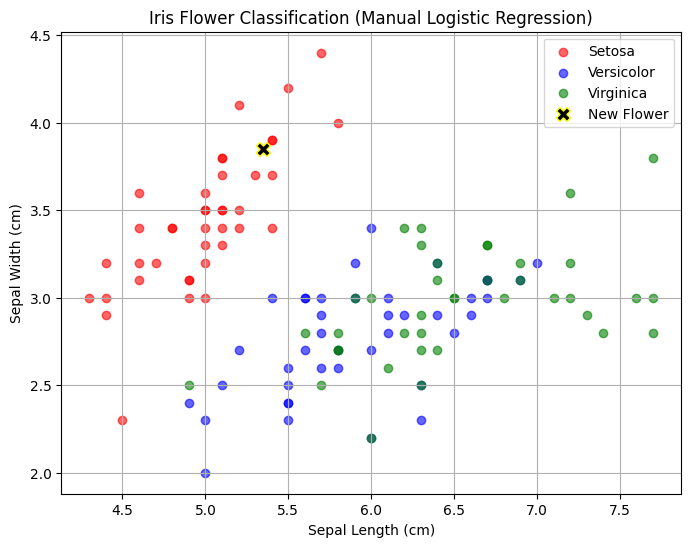

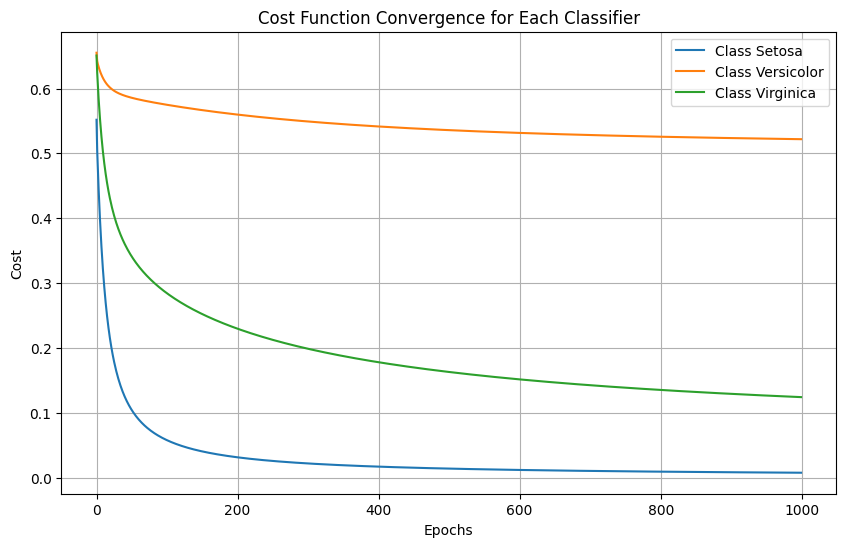

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def loadIrisData(path):
    df = pd.read_csv(path, header=None)
    columns = ['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth', 'species']
    df.columns = columns

    # Map species names to integers (Setosa -> 0, Versicolor -> 1, Virginica -> 2)
    speciesMapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
    df['species'] = df['species'].map(speciesMapping)

    X = df[['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth']].values
    y = df['species'].values

    return X, y

# Sigmoid activation function
def sigmoid(z):
    """Compute the sigmoid activation."""
    return 1 / (1 + np.exp(-z))

# compute the logistic regression cost function (Binary Cross-Entropy Loss)
def computeCost(X, y, theta):
    """Compute the cost function for logistic regression."""
    m = len(y)
    h = sigmoid(X.dot(theta))
    cost = (1/m) * np.sum(-y * np.log(h + 1e-5) - (1 - y) * np.log(1 - h + 1e-5))
    return cost

# perform gradient descent to optimize theta
def gradientDescent(X, y, theta, learningRate, iterations):
    """Perform gradient descent to minimize the cost function."""
    m = len(y)
    costHistory = []

    for _ in range(iterations):
        h = sigmoid(X.dot(theta))
        gradient = (1/m) * X.T.dot(h - y)
        theta -= learningRate * gradient
        cost = computeCost(X, y, theta)
        costHistory.append(cost)  # save cost at each iteration

    return theta, costHistory

# Train one-vs-rest classifiers (one binary classifier per class)
def trainOneVsRest(X, y, numClasses, learningRate=0.1, iterations=1000):
    """Train one classifier per class (one-vs-rest approach)."""
    m, n = X.shape
    allTheta = np.zeros((numClasses, n))
    allCostHistory = []  # save cost history for each class

    for c in range(numClasses):
        theta = np.zeros(n)
        yC = (y == c).astype(int)  # Create binary labels for class c
        theta, costHistory = gradientDescent(X, yC, theta, learningRate, iterations)
        allTheta[c] = theta
        allCostHistory.append(costHistory)

    return allTheta, allCostHistory

# Predict the class for each example based on highest probability
def predictOneVsRest(X, allTheta):
    probabilities = sigmoid(X.dot(allTheta.T))
    return np.argmax(probabilities, axis=1)

# Split dataset manually into training and test sets
def manualTrainTestSplit(X, y, testSize=0.2, randomState=42):
    np.random.seed(randomState)
    indices = np.random.permutation(len(X))
    testSetSize = int(len(X) * testSize)
    testIndices = indices[:testSetSize]
    trainIndices = indices[testSetSize:]
    return X[trainIndices], X[testIndices], y[trainIndices], y[testIndices]

X, y = loadIrisData('iris.data')

# Add intercept term (bias column) manually
X = np.c_[np.ones((X.shape[0], 1)), X]

# Split the data manually into train and test sets
XTrain, XTest, yTrain, yTest = manualTrainTestSplit(X, y)

# Train the logistic regression model
numClasses = 3
allTheta, allCostHistory = trainOneVsRest(XTrain, yTrain, numClasses, learningRate=0.1, iterations=1000)

# Evaluate the model on test data
yPred = predictOneVsRest(XTest, allTheta)
accuracy = np.mean(yPred == yTest)
print(f"Accuracy of the model (manual implementation): {accuracy:.2f}")

# Predict the species for a new flower
newFlower = np.array([1, 5.35, 3.85, 1.25, 0.4])  # intercept + features
predictedClass = predictOneVsRest(newFlower.reshape(1, -1), allTheta)

# Map numerical class back to species name
speciesMappingInverse = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
print(f"The predicted species for the flower is: {speciesMappingInverse[predictedClass[0]]}")

# Plot training data (using first two features for visualization)
plt.figure(figsize=(8, 6))

colors = ['red', 'blue', 'green']
labels = ['Setosa', 'Versicolor', 'Virginica']

for i in range(3):
    plt.scatter(
        XTrain[yTrain == i][:, 1],  # Sepal length
        XTrain[yTrain == i][:, 2],  # Sepal width
        color=colors[i],
        label=labels[i],
        alpha=0.6
    )

# Highlight the new flower prediction
plt.scatter(
    5.35, 3.85,
    color='black',
    label='New Flower',
    edgecolor='yellow',
    s=100,
    marker='X'
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Flower Classification (Manual Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

# Plot cost function for each classifier
plt.figure(figsize=(10, 6))
for i, costHistory in enumerate(allCostHistory):
    plt.plot(costHistory, label=f'Class {labels[i]}')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost Function Convergence for Each Classifier')
plt.legend()
plt.grid(True)
plt.show()


## CERINTE OPTIONALE

Rezolvarea unei probleme de regresie/clasificare prin:

* folosirea validarii încrucișate
* investigarea diferitelor funcții de loss
* ce se întîmplă în cazul clasificarii binare daca se modifică pragul de decizie din 0.5 în alte valori. Cum se poate aprecia calitatea clasificatorului pentru diferite valori ale pragului?

**Validarea încrucișată (Cross-Validation)**

Ce e?

În loc să împarți datele o singură dată în train/test, împarți de mai multe ori în folduri.

Ex: 5-fold Cross-Validation ➔ datele sunt împărțite în 5 părți egale:

4 folduri pentru antrenare, 1 pentru testare, și rotești fiecare fold la rând.

De ce?

* Ca să nu "depindem" de o singură împărțire random.
* Ca să obținem o estimare mai stabilă a performanței.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset from local file
def loadIrisData(path):
    df = pd.read_csv(path, header=None)
    columns = ['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth', 'species']
    df.columns = columns

    # Map species names to integers
    speciesMapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
    df['species'] = df['species'].map(speciesMapping)

    X = df[['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth']].values
    y = df['species'].values

    return X, y

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Compute the logistic regression cost function
def computeCost(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    cost = (1/m) * np.sum(-y * np.log(h + 1e-5) - (1 - y) * np.log(1 - h + 1e-5))
    return cost

# Perform gradient descent to optimize theta
def gradientDescent(X, y, theta, learningRate, iterations):
    m = len(y)
    costHistory = []

    for _ in range(iterations):
        h = sigmoid(X.dot(theta))
        gradient = (1/m) * X.T.dot(h - y)
        theta -= learningRate * gradient
        cost = computeCost(X, y, theta)
        costHistory.append(cost)

    return theta, costHistory

# Train one-vs-rest classifiers (one binary classifier per class)
def trainOneVsRest(X, y, numClasses, learningRate=0.1, iterations=1000):
    m, n = X.shape
    allTheta = np.zeros((numClasses, n))
    allCostHistory = []

    for c in range(numClasses):
        theta = np.zeros(n)
        yC = (y == c).astype(int)  # Binary labels for current class
        theta, costHistory = gradientDescent(X, yC, theta, learningRate, iterations)
        allTheta[c] = theta
        allCostHistory.append(costHistory)

    return allTheta, allCostHistory

# Predict the class for each example
def predictOneVsRest(X, allTheta):
    probabilities = sigmoid(X.dot(allTheta.T))
    return np.argmax(probabilities, axis=1)

# Perform K-Fold Cross Validation manually
def kFoldCrossValidation(X, y, k=5, learningRate=0.1, iterations=1000):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    foldSize = len(X) // k
    accuracies = []

    for fold in range(k):
        start = fold * foldSize
        end = start + foldSize
        testIndices = indices[start:end]
        trainIndices = np.concatenate([indices[:start], indices[end:]])

        XTrain, XTest = X[trainIndices], X[testIndices]
        yTrain, yTest = y[trainIndices], y[testIndices]

        allTheta, _ = trainOneVsRest(XTrain, yTrain, numClasses=3, learningRate=learningRate, iterations=iterations)
        yPred = predictOneVsRest(XTest, allTheta)
        accuracy = np.mean(yPred == yTest)
        accuracies.append(accuracy)

        print(f"Fold {fold+1} Accuracy: {accuracy:.2f}")

    print(f"\nAverage Cross-Validation Accuracy: {np.mean(accuracies):.2f}")

# Main execution
X, y = loadIrisData('iris.data')

# Add intercept term (bias column)
X = np.c_[np.ones((X.shape[0], 1)), X]

# Perform 5-Fold Cross Validation
kFoldCrossValidation(X, y, k=5, learningRate=0.1, iterations=1000)


Fold 1 Accuracy: 1.00
Fold 2 Accuracy: 0.93
Fold 3 Accuracy: 0.93
Fold 4 Accuracy: 0.97
Fold 5 Accuracy: 0.97

Average Cross-Validation Accuracy: 0.96


# Funcții de Loss în Probleme de Clasificare și Regresie

În învățarea automată, funcția de loss măsoară cât de bine se comportă modelul în timpul antrenării.

O funcție de loss primește ca input predicțiile modelului și valorile reale și returnează o eroare scalară, care trebuie minimizată.

Există diferite funcții de loss pentru diferite tipuri de probleme:


## 1. Funcția de Loss pentru Regresie

În regresie (probleme de predicție a valorilor continue), se folosesc cel mai des:

- **Mean Squared Error (MSE)**:

$$
MSE = \frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2
$$

unde:
- $m$ este numărul de exemple,
- $y^{(i)}$ este valoarea reală,
- $\hat{y}^{(i)}$ este valoarea prezisă.

MSE penalizează mai tare erorile mari și este sensibil la outlieri.


## 2. Funcția de Loss pentru Clasificare Binara

În clasificare binară (etichete $y \in \{0,1\}$), se folosește:

- **Binary Cross-Entropy Loss** (sau Log Loss):

$$
L(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right)
$$

unde:
- $\hat{y}^{(i)} = \sigma(z^{(i)})$ este predicția logistică (sigmoid),
- $\sigma(z) = \frac{1}{1 + e^{-z}}$.

Această funcție penalizează predicțiile sigure, dar greșite, mai sever.



## 3. Funcția de Loss pentru Clasificare Multiclass (Softmax)

Dacă sunt mai multe clase ($y \in \{0,1,...,K-1\}$), folosim:

- **Categorical Cross-Entropy** (cu Softmax):

$$
L(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{y}_k^{(i)})
$$

unde:
- $\hat{y}_k^{(i)}$ este probabilitatea prezisă pentru clasa $k$ (calculată cu Softmax),
- $y_k^{(i)}$ este eticheta reală codificată one-hot.

Softmax pentru clasa $k$:

$$
\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$


### Observații despre Funcțiile de Loss

- Loss-ul este optimizat în timpul antrenării prin metode precum **Gradient Descent**.
- În general, vrem ca loss-ul să fie cât mai mic pe setul de antrenare și validare.
- Dacă loss-ul pe validare este mult mai mare decât pe antrenare, modelul suferă de **overfitting**.


## Modificarea Pragului de Decizie în Clasificare Binara

În logistic regression binară, pragul de decizie este de obicei $0.5$.

- Dacă $\hat{y} \geq 0.5$ => prezicem clasa 1.
- Dacă $\hat{y} < 0.5$ => prezicem clasa 0.

**Dacă modificăm pragul** (de exemplu, la $0.3$ sau $0.7$):
- **Mai mic** prag $\rightarrow$ mai multe exemple prezise ca pozitive.
- **Mai mare** prag $\rightarrow$ mai multe exemple prezise ca negative.



## Cum evaluăm clasificatorul pentru diverse praguri?

- **Curba ROC** (Receiver Operating Characteristic) - variază pragul și plotează rata de adevărate pozitive vs. rata de false pozitive.
- **AUC (Area Under Curve)** - măsoară performanța globală.
- **Precision-Recall Curve** - mai utilă când datele sunt dezechilibrate (puține exemple pozitive).

Alegerea pragului optim depinde de problemă (de exemplu, în medicină, preferăm sensibilitate mare pentru a nu rata cazuri pozitive).



Modificarea pragului de decizie în clasificarea binară afectează modul în care sunt clasificate instanțele ca pozitive sau negative. Dacă pragul este mai mic de 0.5, mai multe instanțe vor fi clasificate ca pozitive, dar riscul de **fals pozitive** crește. Dacă pragul este mai mare de 0.5, mai multe instanțe vor fi clasificate ca negative, iar **fals pozitivele** scad, dar poate scădea **recall-ul**.

Pentru a evalua performanța unui model pentru diferite praguri, se folosesc:
1. **Curba Precision-Recall (PR)** pentru a evalua **precizia** și **recall-ul**.
2. **Curba ROC și AUC** pentru a măsura performanța globală.
3. **Scorul F1** pentru un echilibru între precizie și recall.

Alegerea pragului optim depinde de aplicație (de exemplu, în medicină poate fi important să ai un **recall mare**).